# Linear decoding: shared embeddings vs raw neural population

Using the two **no-category** MultiHeadTransformer models (global SigLIP target `hvm`, object-crop SigLIP target `hvm_obj`), we extract the 512-d shared embedding for all 450 HVM stimuli and train cross-validated linear decoders for:

- **Category** (10-way classification)
- **Scale** `s` (regression)
- **Translation** `ty`, `tz` (regression)
- **Rotation** `rxy`, `rxz`, `ryz` (regression)

We repeat the same decoders on the **raw neural population** (mean-FR over time window) and compare all three side-by-side.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegressionCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, r2_score
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import (
    SEED, HVM_N_STIMULI, HVM_N_VAR, HVM_N_CAT,
    HVM_METADATA_PATH,
)
from data_utils.hvm_loader import _load_hvm_neural
from encoders import MultiHeadTransformer

DEVICE = 'cpu'
GLOBAL_CKPT = Path(
    'checkpoints/multihead/hvm/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs128_ws1.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
OBJ_CKPT = Path(
    'checkpoints/multihead/hvm_obj/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs64_ws5.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
N_CV_FOLDS = 5

print('Imports OK')


Imports OK


In [2]:
# ── Load metadata labels ──────────────────────────────────────────────────────
with open(HVM_METADATA_PATH) as f:
    meta = json.load(f)

meta_sorted = sorted(meta, key=lambda x: x['idx'])

CATEGORIES = ('apple','bear','car','chair','dog','elephant','head','plane','table','turtle')
cat_to_int = {c: i for i, c in enumerate(CATEGORIES)}

y_cat = np.array([cat_to_int[m['category']] for m in meta_sorted])  # (450,)
y_s   = np.array([m['s']   for m in meta_sorted])                    # scale
y_ty  = np.array([m['ty']  for m in meta_sorted])                    # y-translation
y_tz  = np.array([m['tz']  for m in meta_sorted])                    # z-translation
y_rxy = np.array([m['rxy'] for m in meta_sorted])                    # rotation xy
y_rxz = np.array([m['rxz'] for m in meta_sorted])                    # rotation xz
y_ryz = np.array([m['ryz'] for m in meta_sorted])                    # rotation yz

print(f'Labels loaded: {len(y_cat)} stimuli')
print(f'Category distribution: {np.bincount(y_cat)}')

Labels loaded: 450 stimuli
Category distribution: [45 45 45 45 45 45 45 45 45 45]


In [3]:
# ── Build raw neural feature (mean over time window) ─────────────────────────
rsp, _, _ = _load_hvm_neural()           # (450, n_neurons, T)
X_neural = rsp.mean(axis=2)              # (450, n_neurons)
print(f'Neural population shape: {X_neural.shape}')


Loading HVM sessions:   0%|          | 0/5 [00:00<?, ?it/s]

Loading HVM sessions: 100%|██████████| 10/10 [00:40<00:00,  4.02s/it]


Neural population shape: (450, 2330)


In [4]:
# ── Extract shared embeddings from both no-category models ───────────────────
def extract_shared(ckpt_path, rsp):
    ckpt = torch.load(ckpt_path, weights_only=False, map_location='cpu')
    args = ckpt['args']
    n_neurons_total = rsp.shape[1]
    n_cat = HVM_N_CAT if args.get('use_category', False) else 0
    model = MultiHeadTransformer(
        n_neurons   = n_neurons_total,
        d_model     = int(args['d_model']),
        n_heads     = int(args['n_heads']),
        n_layers    = int(args['n_layers']),
        shared_dim  = int(args['shared_dim']),
        dropout     = 0.0,
        n_categories= n_cat,
    )
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    neural_tensor = torch.from_numpy(rsp).float()
    embeds = []
    with torch.no_grad():
        for i in range(HVM_N_STIMULI):
            x = neural_tensor[i:i+1].permute(0, 2, 1)  # (1, T, neurons)
            embeds.append(model(x, cat=None)['shared'].squeeze(0).numpy())
    return np.stack(embeds)

X_global = extract_shared(GLOBAL_CKPT, rsp)
print(f'Global model shared embedding: {X_global.shape}')

X_obj = extract_shared(OBJ_CKPT, rsp)
print(f'Obj model shared embedding:    {X_obj.shape}')


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Global model shared embedding: (450, 512)
Obj model shared embedding:    (450, 512)


In [5]:
# ── Cross-validated linear decoding ──────────────────────────────────────────

def decode_classification(X, y, n_folds=N_CV_FOLDS, seed=SEED):
    """Stratified k-fold logistic regression, returns per-fold accuracy."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    accs = []
    for train_idx, test_idx in tqdm(skf.split(X, y), total=n_folds, desc='folds', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                Cs=10, cv=3, max_iter=500,
                solver='lbfgs', l1_ratios=(0,),
                use_legacy_attributes=False,
                random_state=seed, n_jobs=-1,
            )),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        accs.append(accuracy_score(y[test_idx], pipe.predict(X[test_idx])))
    return np.array(accs)


def decode_regression(X, y, n_folds=N_CV_FOLDS, seed=SEED):
    """K-fold Ridge regression, returns per-fold R²."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    r2s = []
    for train_idx, test_idx in tqdm(kf.split(X), total=n_folds, desc='folds', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', RidgeCV(alphas=np.logspace(-3, 5, 20))),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        r2s.append(r2_score(y[test_idx], pipe.predict(X[test_idx])))
    return np.array(r2s)


print('Decoder helpers defined')

Decoder helpers defined


In [6]:
# ── Run all decoders ──────────────────────────────────────────────────────────
reg_targets = {
    'Scale (s)':        y_s,
    'Translation ty':   y_ty,
    'Translation tz':   y_tz,
    'Rotation rxy':     y_rxy,
    'Rotation rxz':     y_rxz,
    'Rotation ryz':     y_ryz,
}

print('Category (classification) ...')
cat_global = decode_classification(X_global, y_cat)
cat_obj    = decode_classification(X_obj,    y_cat)
cat_neural = decode_classification(X_neural, y_cat)

reg_global, reg_obj, reg_neural = {}, {}, {}
for name, y in tqdm(reg_targets.items(), desc='regression targets'):
    reg_global[name] = decode_regression(X_global, y)
    reg_obj[name]    = decode_regression(X_obj,    y)
    reg_neural[name] = decode_regression(X_neural, y)

print('Done.')


Category (classification) ...


folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

regression targets:   0%|          | 0/6 [00:00<?, ?it/s]

...

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

Done.


In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd

chance_cat = 1.0 / HVM_N_CAT

rows = []
rows.append(dict(
    Task='Category (accuracy)',
    Metric='Accuracy',
    Global=f'{cat_global.mean():.3f} ± {cat_global.std():.3f}',
    Obj=f'{cat_obj.mean():.3f} ± {cat_obj.std():.3f}',
    Neural=f'{cat_neural.mean():.3f} ± {cat_neural.std():.3f}',
    Chance=f'{chance_cat:.3f}',
))
for name in reg_targets:
    rows.append(dict(
        Task=name,
        Metric='R²',
        Global=f'{reg_global[name].mean():.3f} ± {reg_global[name].std():.3f}',
        Obj=f'{reg_obj[name].mean():.3f} ± {reg_obj[name].std():.3f}',
        Neural=f'{reg_neural[name].mean():.3f} ± {reg_neural[name].std():.3f}',
        Chance='0.000',
    ))

df = pd.DataFrame(rows).set_index('Task')
print(df.to_string())


                       Metric          Global             Obj          Neural Chance
Task                                                                                
Category (accuracy)  Accuracy   0.318 ± 0.040   0.300 ± 0.040   0.444 ± 0.048  0.100
Scale (s)                  R²   0.017 ± 0.032   0.030 ± 0.022   0.041 ± 0.038  0.000
Translation ty             R²  -0.007 ± 0.046  -0.006 ± 0.048   0.059 ± 0.073  0.000
Translation tz             R²   0.097 ± 0.053   0.091 ± 0.072   0.165 ± 0.087  0.000
Rotation rxy               R²  -0.011 ± 0.005  -0.011 ± 0.008  -0.009 ± 0.009  0.000
Rotation rxz               R²  -0.005 ± 0.013  -0.003 ± 0.013  -0.003 ± 0.015  0.000
Rotation ryz               R²  -0.008 ± 0.008  -0.016 ± 0.024  -0.011 ± 0.009  0.000


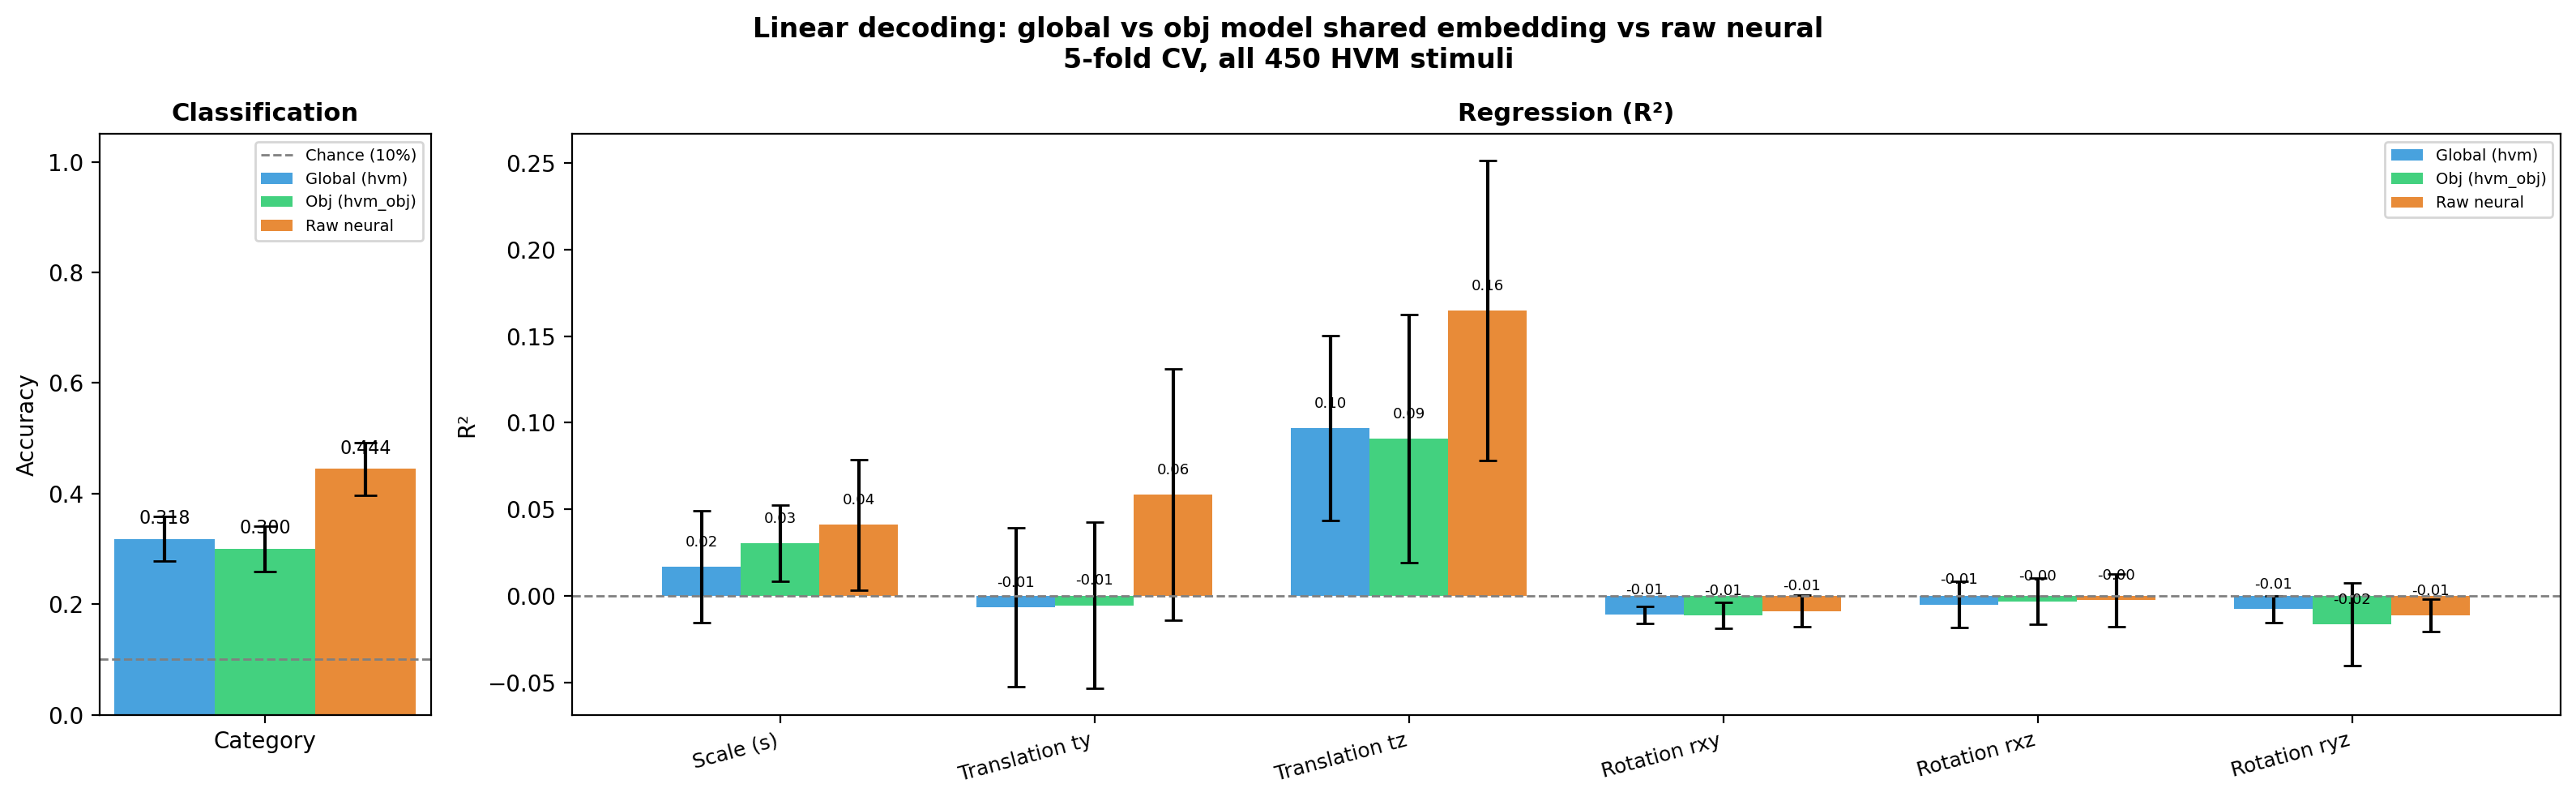

Saved to outputs/linear_decode_nocat.pdf


In [8]:
# ── Plot: grouped bar chart ──────────────────────────────────────────────────
all_task_names = ['Category'] + list(reg_targets.keys())

color_global = '#3498db'
color_obj    = '#2ecc71'
color_neural = '#e67e22'
width = 0.25

def task_arrays(cat_res, reg_res):
    means = np.array([cat_res.mean()] + [reg_res[n].mean() for n in reg_targets])
    stds  = np.array([cat_res.std()]  + [reg_res[n].std()  for n in reg_targets])
    return means, stds

g_means, g_stds = task_arrays(cat_global, reg_global)
o_means, o_stds = task_arrays(cat_obj,    reg_obj)
n_means, n_stds = task_arrays(cat_neural, reg_neural)

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [1, 6]})

# ---- left: category ----
ax0 = axes[0]
for offset, means, stds, color, label in [
    (-width, g_means[:1], g_stds[:1], color_global, 'Global (hvm)'),
    (0,      o_means[:1], o_stds[:1], color_obj,    'Obj (hvm_obj)'),
    (+width, n_means[:1], n_stds[:1], color_neural, 'Raw neural'),
]:
    ax0.bar(offset, means[0], width, yerr=stds[0], color=color,
            capsize=5, alpha=0.9, label=label)
    ax0.text(offset, means[0] + 0.02, f'{means[0]:.3f}',
             ha='center', va='bottom', fontsize=8)
ax0.axhline(chance_cat, color='grey', ls='--', lw=1, label='Chance (10%)')
ax0.set_xticks([0]); ax0.set_xticklabels(['Category'], fontsize=10)
ax0.set_ylabel('Accuracy', fontsize=10); ax0.set_ylim(0, 1.05)
ax0.set_title('Classification', fontweight='bold', fontsize=11)
ax0.legend(fontsize=7)

# ---- right: regression ----
ax1 = axes[1]
reg_names = list(reg_targets.keys())
r_x = np.arange(len(reg_names))

for offset, res, color, label in [
    (-width, reg_global, color_global, 'Global (hvm)'),
    (0,      reg_obj,    color_obj,    'Obj (hvm_obj)'),
    (+width, reg_neural, color_neural, 'Raw neural'),
]:
    means = np.array([res[n].mean() for n in reg_names])
    stds  = np.array([res[n].std()  for n in reg_names])
    ax1.bar(r_x + offset, means, width, yerr=stds,
            color=color, capsize=4, alpha=0.9, label=label)
    for x_pos, v in zip(r_x + offset, means):
        ax1.text(x_pos, v + 0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=6.5)

ax1.axhline(0, color='grey', ls='--', lw=1)
ax1.set_xticks(r_x); ax1.set_xticklabels(reg_names, fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('R²', fontsize=10)
ax1.set_title('Regression (R²)', fontweight='bold', fontsize=11)
ax1.legend(fontsize=7)

fig.suptitle(
    f'Linear decoding: global vs obj model shared embedding vs raw neural\n'
    f'{N_CV_FOLDS}-fold CV, all 450 HVM stimuli',
    fontsize=12, fontweight='bold',
)
fig.tight_layout()
out_path = Path('outputs/linear_decode_nocat.pdf')
out_path.parent.mkdir(exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')


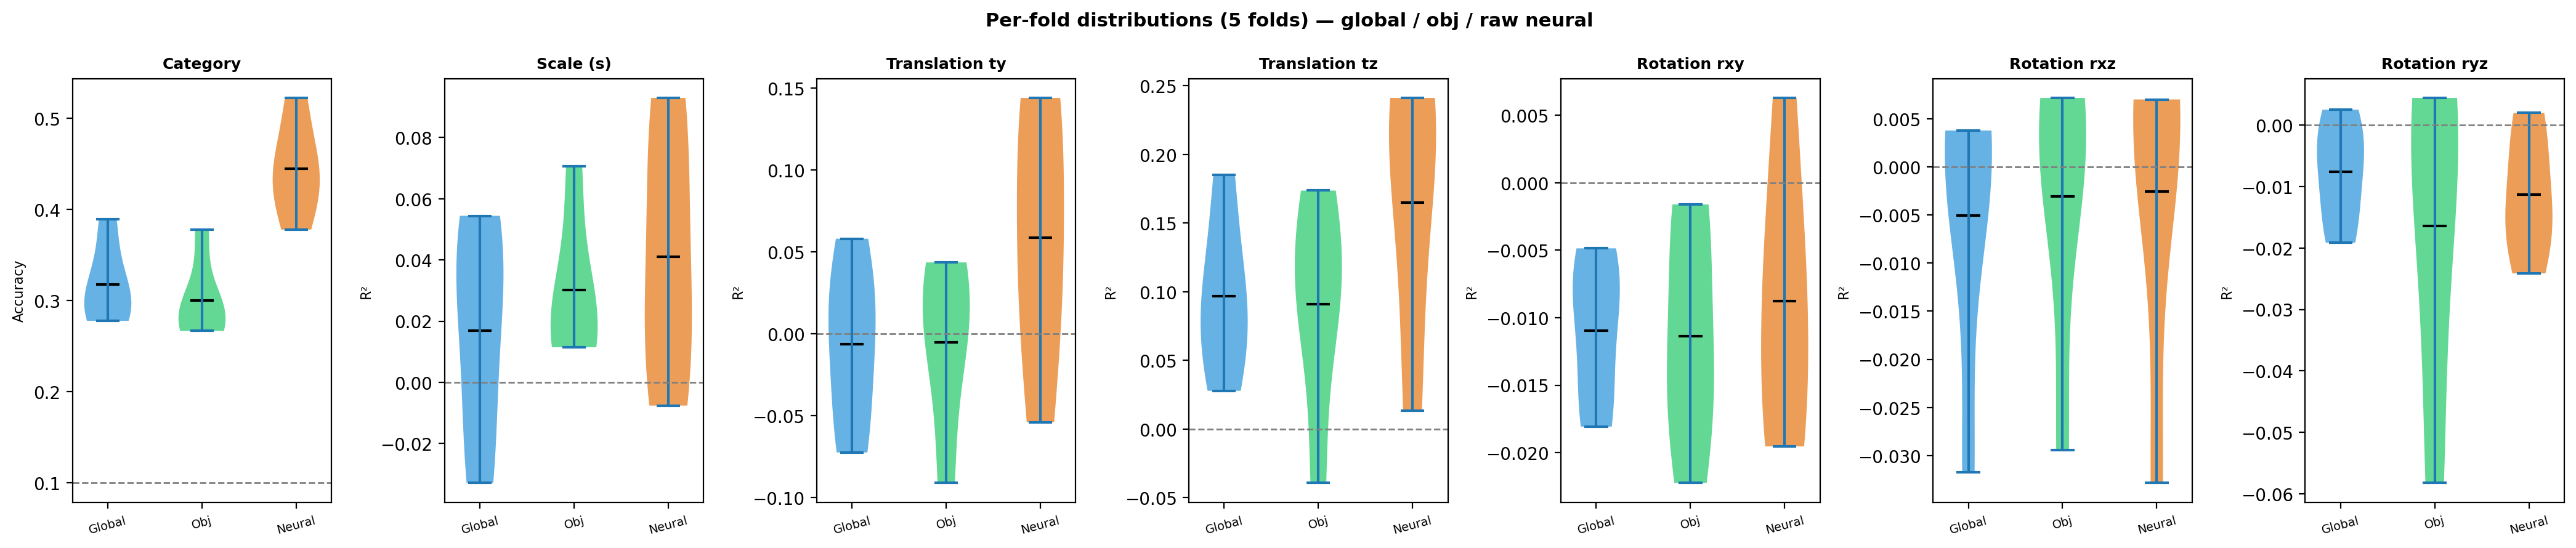

In [9]:
# ── Per-fold detail (violin plot) ────────────────────────────────────────────
n_tasks = len(all_task_names)
fig2, axes2 = plt.subplots(1, n_tasks, figsize=(3 * n_tasks, 4.5), sharey=False)

fold_global = [cat_global] + [reg_global[n] for n in reg_targets]
fold_obj    = [cat_obj]    + [reg_obj[n]    for n in reg_targets]
fold_neural = [cat_neural] + [reg_neural[n] for n in reg_targets]
ylabels = ['Accuracy'] + ['R²'] * len(reg_targets)

for ax, name, fg, fo, fn, ylabel in zip(
    axes2, all_task_names, fold_global, fold_obj, fold_neural, ylabels
):
    vp = ax.violinplot([fg, fo, fn], positions=[1, 2, 3],
                       showmeans=True, showextrema=True)
    for body, color in zip(vp['bodies'], [color_global, color_obj, color_neural]):
        body.set_facecolor(color); body.set_alpha(0.75)
    vp['cmeans'].set_color('black')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Global', 'Obj', 'Neural'], fontsize=7, rotation=15)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.axhline(chance_cat if name == 'Category' else 0,
               color='grey', ls='--', lw=1)

fig2.suptitle(
    f'Per-fold distributions ({N_CV_FOLDS} folds) — global / obj / raw neural',
    fontsize=11, fontweight='bold',
)
fig2.tight_layout()
plt.savefig('outputs/linear_decode_nocat_violin.pdf', bbox_inches='tight')
plt.show()
